In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# <i><b> Predictive Insight Engine


##### <i> Q1. Supervised Learning Algorithms  </i>

Supervised learning algorithms learn a mapping from input features (X) to output labels (y) using labeled training data. The model is "supervised" because every training sample has a known correct answer. Examples include Linear Regression, Decision Trees, SVMs, and Neural Networks.

##### <i> Q2. Regression vs Classification </i>

Regression predicts a continuous numerical output (e.g., house price in INR), while Classification predicts a discrete category (e.g., spam/not-spam). Loss functions differ: regression typically uses MSE; classification uses cross-entropy or log-loss.

##### <i> Q3. Simple Linear Regression </i>

Simple Linear Regression models the relationship between one independent variable (X) and one dependent variable (y) using a straight line: y = b0 + b1*X + e. b0 is the intercept, b1 is the slope, and e is the error term. Parameters are estimated by minimising the Sum of Squared Residuals (OLS).

##### <i> Q4. Assumptions of Linear Regression </i>

1. Linearity: relationship between X and y is linear.
2. Independence: observations are independent.
3. Homoscedasticity: constant variance of residuals.
4. Normality: residuals are normally distributed.
5. No multicollinearity: predictors are not highly correlated.

##### <i> Q5. Bias-Variance Trade-Off </i>

Bias is error from oversimplified assumptions (underfitting); Variance is error from sensitivity to training-data fluctuations (overfitting). Total Error = Bias² + Variance + Irreducible Noise. A good model balances both: complex models lower bias but raise variance, and vice versa.

##### <i> Q6. Overfitting and Underfitting </i>

Overfitting: model memorises training data (high train accuracy, poor test accuracy). Example: polynomial degree 15 on 50 data points.

Underfitting: model is too simple to capture patterns (poor train AND test accuracy). Example: fitting a straight line to non-linear data.


### <b>Part B</b>: <i>Dataset Understanding & Preparation

In [2]:
df = pd.read_csv('HousePrice.csv')

In [3]:
print(f"Dataset Shape : {df.shape}")

Dataset Shape : (4200, 12)


In [4]:
print(f"Columns : {list(df.columns)}")

Columns : ['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage', 'has_pool', 'renovation_years_ago', 'house_price_inr']


In [5]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [6]:
print("Basic Statistics:")
print(df.describe().round(2))

Basic Statistics:
        house_id  area_sqft  bedrooms  bathrooms  location_score  age_years  \
count    4200.00    4200.00   4200.00    4200.00         4200.00    4200.00   
mean   102100.50    1667.36      3.70       2.83            5.61      23.83   
std      1212.58     630.34      1.57       1.15            2.14      13.95   
min    100001.00     450.00      1.00       1.00            1.00       1.00   
25%    101050.75    1226.75      3.00       2.00            4.00      13.00   
50%    102100.50    1660.00      4.00       3.00            5.70      21.00   
75%    103150.25    2084.25      5.00       4.00            7.30      32.00   
max    104200.00    4202.00      7.00       6.00           10.00      80.00   

       distance_city_km  lot_size_sqft  has_garage  has_pool  \
count           4200.00        4200.00     4200.00   4200.00   
mean              18.19        3366.33        0.64      0.10   
std                8.67        1658.23        0.48      0.29   
min           

In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
house_id                0
area_sqft               0
bedrooms                0
bathrooms               0
location_score          0
age_years               0
distance_city_km        0
lot_size_sqft           0
has_garage              0
has_pool                0
renovation_years_ago    0
house_price_inr         0
dtype: int64


In [8]:
print("Data Types:")
print(df.dtypes)

Data Types:
house_id                  int64
area_sqft                 int64
bedrooms                  int64
bathrooms                 int64
location_score          float64
age_years                 int64
distance_city_km        float64
lot_size_sqft             int64
has_garage                int64
has_pool                  int64
renovation_years_ago      int64
house_price_inr           int64
dtype: object


In [9]:
FEATURES = ['area_sqft', 'bedrooms', 'bathrooms', 'location_score',
            'age_years', 'distance_city_km', 'lot_size_sqft',
            'has_garage', 'has_pool', 'renovation_years_ago']
TARGET   = 'house_price_inr'

X = df[FEATURES]
y = df[TARGET]

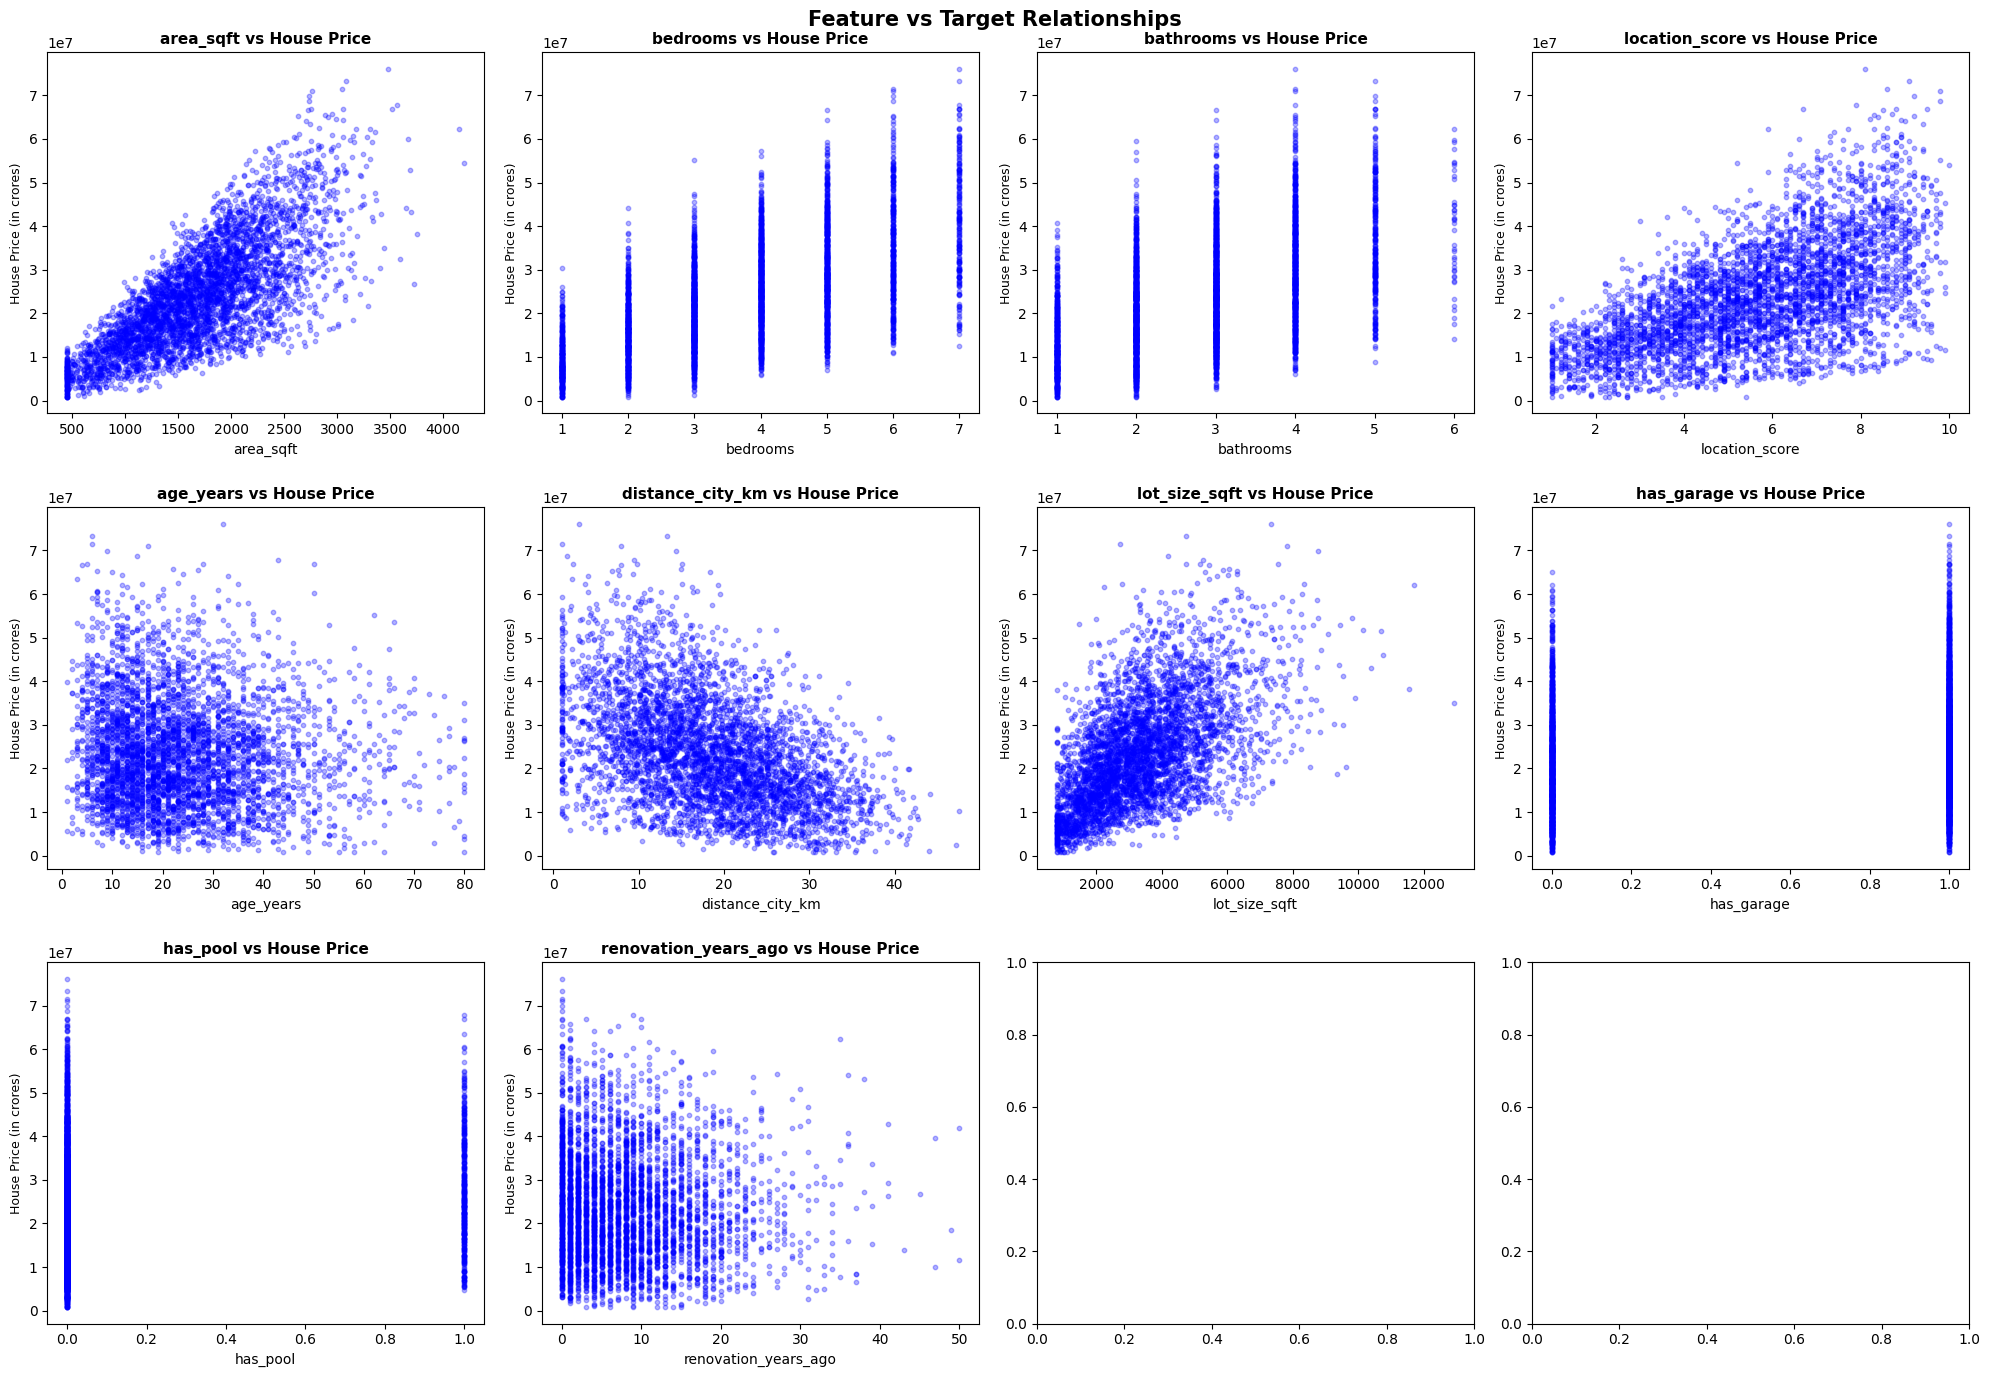

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].scatter(df[feat], df[TARGET], alpha=0.3, color='blue', s=10)
    axes[i].set_xlabel(feat, fontsize=10)
    axes[i].set_ylabel('House Price (in crores)', fontsize=9)
    axes[i].set_title(f'{feat} vs House Price', fontsize=11, fontweight='bold')

plt.suptitle('Feature vs Target Relationships', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('Feature_vs_Target_Relationships.png', dpi=150)
plt.show()

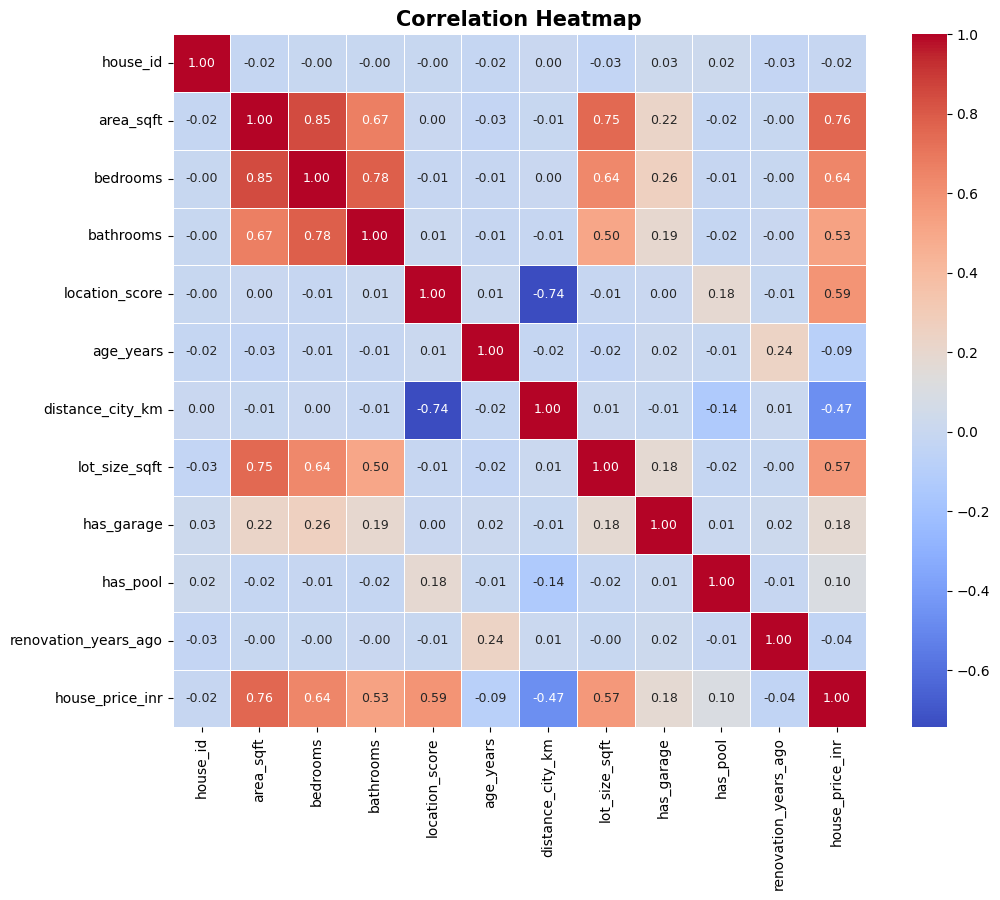

In [11]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(),  annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Heatmap', fontsize=15, fontweight='bold')
plt.savefig('Correlation_Matrix.png', dpi=150)
plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 9009)

### <b>Part C</b>: <i>Simple Linear Regression

In [13]:
slr = LinearRegression()
slr.fit(X_train[['area_sqft']], y_train)
y_pred_slr = slr.predict(X_test[['area_sqft']])

print(f'Intercept: {slr.intercept_:.2f}')
print(f'Coefficient: {slr.coef_[0]:.2f}')

Intercept: -1095775.08
Coefficient: 14840.37


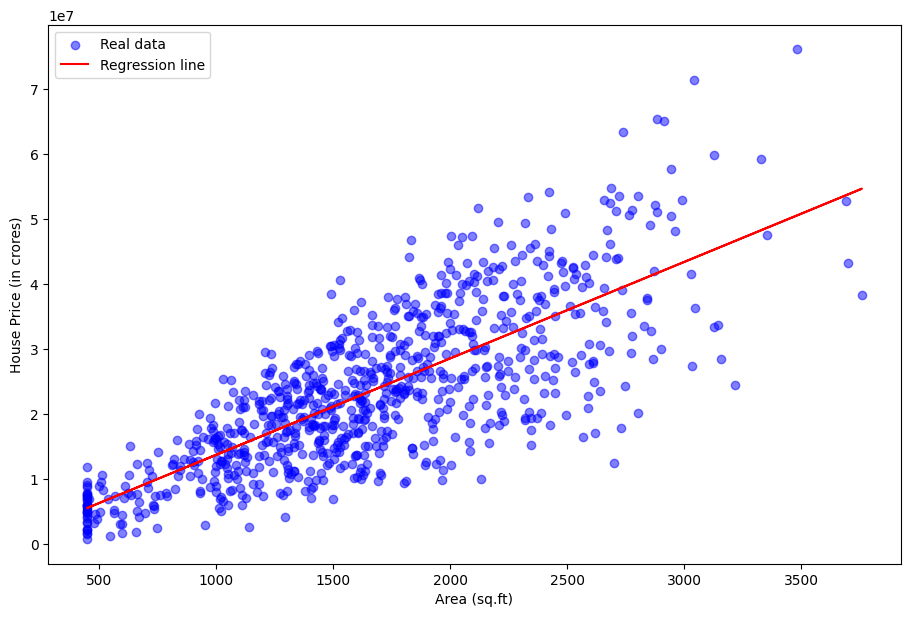

In [14]:
plt.figure(figsize=(11, 7))

plt.scatter(X_test[['area_sqft']], y_test, color = 'blue', label = 'Real data', alpha=0.50)
plt.plot(X_test[['area_sqft']], y_pred_slr, color = 'red', label = 'Regression line')
plt.xlabel('Area (sq.ft)')
plt.ylabel('House Price (in crores)')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Residuals Distribution)')

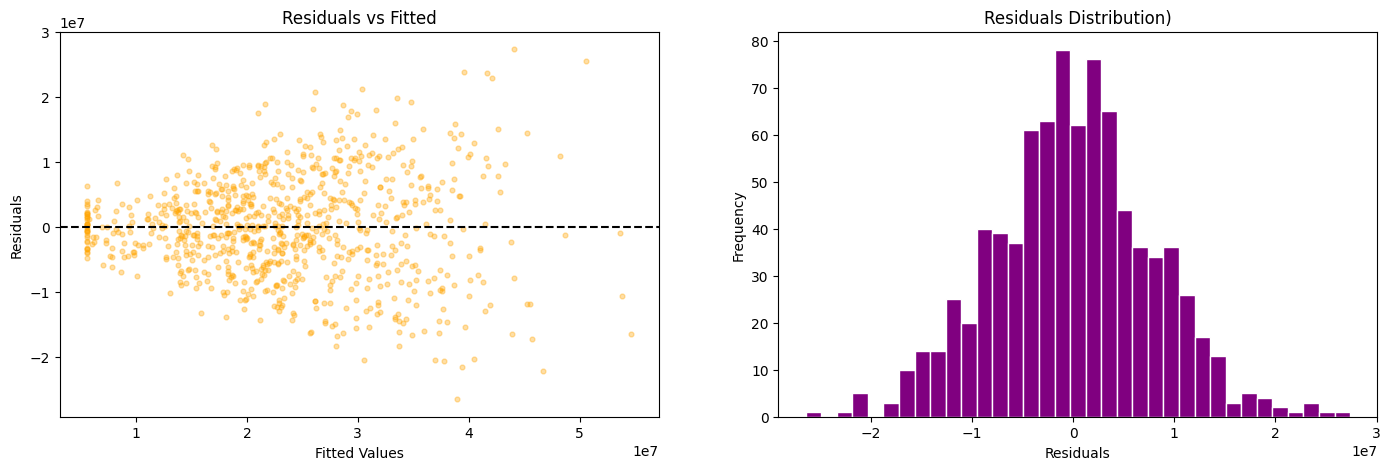

In [15]:
residuals = y_test - y_pred_slr

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

axes[0].scatter(y_pred_slr, residuals, alpha=0.35, color="orange", s=12)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

axes[1].hist(residuals, bins=35, color="purple", edgecolor="white")
axes[1].set_xlabel("Residuals")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residuals Distribution)")

### <b>Part D</b>: <i>Model Evaluation Metrics

In [16]:
results = []

def evaluate_model(name, y_true, y_pred, n_features=1):
    n      = len(y_true)
    mse    = mean_squared_error(y_true, y_pred)
    mae    = mean_absolute_error(y_true, y_pred)
    rmse   = np.sqrt(mse)
    r2     = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

    print(f"\n{'─'*60}")
    print(f"  Model        : {name}")
    print(f"  MSE          : Rs {mse:,.2f}  -> Penalises large errors heavily.")
    print(f"  MAE          : Rs {mae:,.2f}  -> Avg absolute error; robust to outliers.")
    print(f"  RMSE         : Rs {rmse:,.2f}  -> Error in same unit as target (INR).")
    print(f"  R2 Score     :    {r2:.6f}  -> {r2*100:.2f}% variance explained.")
    print(f"  Adjusted R2  :    {adj_r2:.6f}  -> R2 penalised for no. of predictors.")
    print(f"{'─'*60}")

    results.append({
        "Model": name, "MSE": mse, "MAE": mae,
        "RMSE": rmse, "R2": r2, "Adj_R2": adj_r2
    })

evaluate_model("Simple LR (area_sqft only)", y_test, y_pred_slr, n_features=1)


────────────────────────────────────────────────────────────
  Model        : Simple LR (area_sqft only)
  MSE          : Rs 61,716,546,799,793.42  -> Penalises large errors heavily.
  MAE          : Rs 6,158,154.53  -> Avg absolute error; robust to outliers.
  RMSE         : Rs 7,855,987.96  -> Error in same unit as target (INR).
  R2 Score     :    0.588759  -> 58.88% variance explained.
  Adjusted R2  :    0.588268  -> R2 penalised for no. of predictors.
────────────────────────────────────────────────────────────


### <b>Part E</b>: <i>Multiple Linear Regression

In [17]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)
y_pred_mlr = mlr.predict(X_test)

coef_df = pd.DataFrame({"Feature": FEATURES, "Coefficient": mlr.coef_})
coef_df = coef_df.sort_values("Coefficient", ascending=False)

print("\nMLR Coefficients (sorted):")
print(coef_df.to_string(index=False))
print(f"\nIntercept : Rs {mlr.intercept_:,.2f}")


MLR Coefficients (sorted):
             Feature   Coefficient
      location_score  3.120239e+06
            has_pool  3.426493e+05
           bathrooms  1.936642e+05
          has_garage  1.675235e+05
            bedrooms  1.475279e+05
           area_sqft  1.401009e+04
       lot_size_sqft  1.400925e+02
renovation_years_ago -2.223933e+04
           age_years -6.535456e+04
    distance_city_km -9.447629e+04

Intercept : Rs -15,464,299.64


In [18]:
evaluate_model("MLR (All Features)", y_test, y_pred_mlr, n_features=len(X))


────────────────────────────────────────────────────────────
  Model        : MLR (All Features)
  MSE          : Rs 11,291,861,713,235.21  -> Penalises large errors heavily.
  MAE          : Rs 2,503,371.22  -> Avg absolute error; robust to outliers.
  RMSE         : Rs 3,360,336.55  -> Error in same unit as target (INR).
  R2 Score     :    0.924758  -> 92.48% variance explained.
  Adjusted R2  :    1.018783  -> R2 penalised for no. of predictors.
────────────────────────────────────────────────────────────


### <b>Part F</b>: <i>Polynomial Regression

In [19]:
for degree in [1, 2, 3, 4]:

    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train[['area_sqft']])
    X_poly_test = poly.transform(X_test[['area_sqft']])

    lr = LinearRegression()
    lr.fit(X_poly_train, y_train)

    y_pred = lr.predict(X_poly_test)

    evaluate_model(f"Polynomial Regression: Degree = {degree}", y_test, y_pred, n_features=len(X_poly_train))



────────────────────────────────────────────────────────────
  Model        : Polynomial Regression: Degree = 1
  MSE          : Rs 61,716,546,799,793.42  -> Penalises large errors heavily.
  MAE          : Rs 6,158,154.53  -> Avg absolute error; robust to outliers.
  RMSE         : Rs 7,855,987.96  -> Error in same unit as target (INR).
  R2 Score     :    0.588759  -> 58.88% variance explained.
  Adjusted R2  :    1.136863  -> R2 penalised for no. of predictors.
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
  Model        : Polynomial Regression: Degree = 2
  MSE          : Rs 61,664,019,117,020.74  -> Penalises large errors heavily.
  MAE          : Rs 6,153,298.28  -> Avg absolute error; robust to outliers.
  RMSE         : Rs 7,852,644.08  -> Error in same unit as target (INR).
  R2 Score     :    0.589109  -> 58.91% variance explained.
  Adjusted R2  :    1.136746  -> R2 penalised for no. of predictors.

### <b>Part G</b>: <i>Gradient Descent Optimization

### <b>Part H</b>: <i>Bias-Variance & Model Diagnostics

### <b>Part I</b>: <i>Final Analysis & Reporting